In [ ]:
pip install datasets

In [ ]:
from datasets import load_dataset

ds = load_dataset("David-Egea/Creditcard-fraud-detection")

print(ds)
print(ds["train"][0])

DatasetDict({
    train: Dataset({
        features: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class'],
        num_rows: 284807
    })
})
{'Time': 0, 'V1': -1.3598071336738, 'V2': -0.0727811733098497, 'V3': 2.53634673796914, 'V4': 1.37815522427443, 'V5': -0.338320769942518, 'V6': 0.462387777762292, 'V7': 0.239598554061257, 'V8': 0.0986979012610507, 'V9': 0.363786969611213, 'V10': 0.0907941719789316, 'V11': -0.551599533260813, 'V12': -0.617800855762348, 'V13': -0.991389847235408, 'V14': -0.311169353699879, 'V15': 1.46817697209427, 'V16': -0.470400525259478, 'V17': 0.207971241929242, 'V18': 0.0257905801985591, 'V19': 0.403992960255733, 'V20': 0.251412098239705, 'V21': -0.018306777944153, 'V22': 0.277837575558899, 'V23': -0.110473910188767, 'V24': 0.0669280749146731, 'V25': 0.128539358273528, 'V26': -0.189114843888824, 'V27':

In [ ]:
import pandas as pd

df = ds["train"].to_pandas()
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [ ]:
##EDA
print(df.shape)
print(df.columns)

(284807, 31)
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  int64  
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
## checking class distribution(since the data is already anonymized and normalized
print(df["Class"].value_counts())
print(df["Class"].value_counts(normalize=True)*100)

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


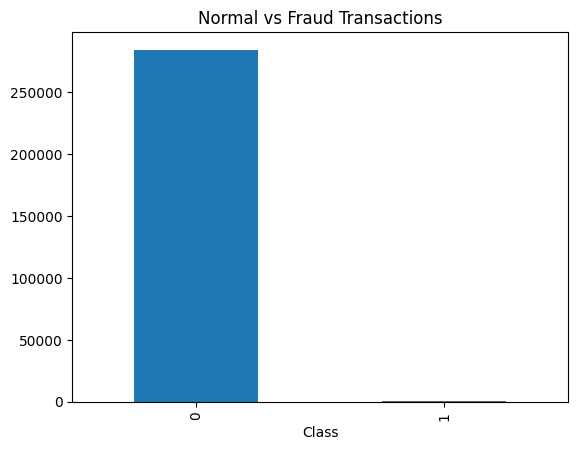

In [ ]:
##vizualizing the imbalance
import matplotlib.pyplot as plt

df["Class"].value_counts().plot(kind="bar")
plt.title("Normal vs Fraud Transactions")
plt.show()

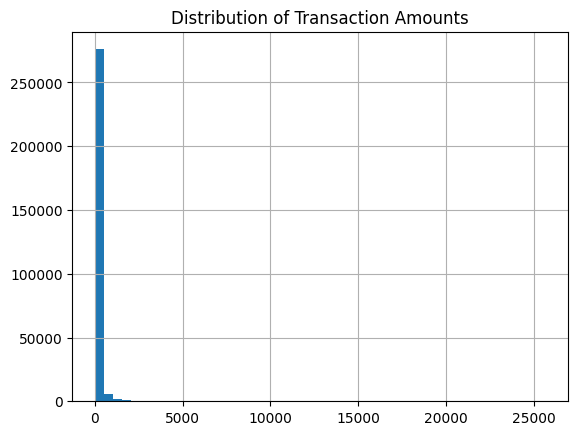

In [ ]:
df["Amount"].hist(bins=50)
plt.title("Distribution of Transaction Amounts")
plt.show()

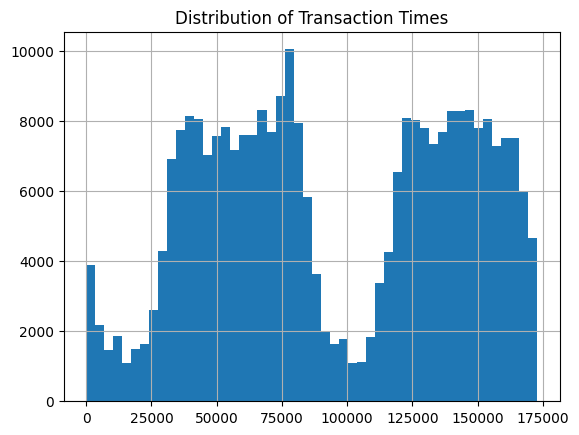

In [ ]:
df["Time"].hist(bins=50)
plt.title("Distribution of Transaction Times")
plt.show()

In [ ]:
## Preparing the data for the anomaly
# Separating feature from labels
X = df.drop("Class", axis=1)
y = df["Class"]

In [ ]:
## Scaling the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
## Using isolation forest (works better, when features are scaled)
from sklearn.ensemble import IsolationForest

model=IsolationForest(n_estimators=100, contamination=0.002, random_state=42)
model.fit(X_scaled)

IsolationForest(contamination=0.002, random_state=42)

In [ ]:
## Generatng predictions
preds = model.predict(X_scaled)

In [ ]:
##converting it to flag a fraud
import numpy as np

preds = np.where(preds == -1, 1, 0)

In [ ]:
## Evaluating the results
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(confusion_matrix(y,preds))
print(classification_report(y,preds))
print(accuracy_score(y, preds))

[[283883    432]
 [   354    138]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.24      0.28      0.26       492

    accuracy                           1.00    284807
   macro avg       0.62      0.64      0.63    284807
weighted avg       1.00      1.00      1.00    284807

0.9972402363705948


In [ ]:
## Next Phase
# Saving the trained model

import joblib
joblib.dump(model, "fraud_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(list(X.columns), "feature_cols.pkl")

['feature_cols.pkl']

In [ ]:
!ls

feature_cols.pkl  main.py     __pycache__	  sample_data
fraud_model.pkl   main_rf.py  rf_fraud_model.pkl  scaler.pkl


In [ ]:
## Creating the prediction model for the inference/production stage
import joblib
import numpy as np

model = joblib.load("fraud_model.pkl")
scaler = joblib.load("scaler.pkl")
feature_cols = joblib.load("feature_cols.pkl")

def predict(data):
    data = data.reindex(columns=feature_cols)  # enforce order
    data_scaled = scaler.transform(data)
    raw = model.predict(data_scaled)
    preds = np.where(raw == -1, 1, 0)
    return preds

In [ ]:
## Testing the prediction model
sample = X.iloc[:5].copy()
print(predict(sample))

[0 0 0 0 0]


In [ ]:
%%writefile main.py
from fastapi import FastAPI
import joblib
import pandas as pd

app = FastAPI()

model = joblib.load("fraud_model.pkl")
scaler = joblib.load("scaler.pkl")
feature_cols = joblib.load("feature_cols.pkl")

@app.get("/")
def home():
    return {"status": "ok", "message": "API is running"}

@app.get("/health")
def health():
    return {"status": "healthy", "model_loaded": True}

@app.post("/predict")
def predict(data: dict):
    df = pd.DataFrame([data])
    df = df.reindex(columns=feature_cols)

    if df.isnull().any().any():
        missing = [col for col in feature_cols if col not in data]
        return {"error": "Missing required features", "missing": missing}

    x_scaled = scaler.transform(df)

    raw_pred = model.predict(x_scaled)[0]
    anomaly_score = model.decision_function(x_scaled)[0]
    fraud_flag = 1 if raw_pred == -1 else 0

    return {
        "fraud_prediction": int(fraud_flag),
        "anomaly_score": float(anomaly_score),
        "raw_model_output": int(raw_pred)
    }

Overwriting main.py


In [ ]:
from importlib import reload
import main
reload(main)

from fastapi.testclient import TestClient
client = TestClient(main.app)

In [ ]:
from fastapi.testclient import TestClient
from main import app

client = TestClient(app)

response = client.get("/")
print(response.status_code)
print(response.json())

200
{'status': 'ok', 'message': 'API is running'}


In [ ]:
sample_row = X.iloc[0].to_dict()

response = client.post("/predict", json=sample_row)
print(response.status_code)
print(response.json())

200
{'fraud_prediction': 0, 'anomaly_score': 0.2679046937846455, 'raw_model_output': 1}


In [ ]:
for i in range(10):
    sample_row = X.iloc[i].to_dict()
    response = client.post("/predict", json=sample_row)
    print(f"Row {i}: {response.json()}")

Row 0: {'fraud_prediction': 0, 'anomaly_score': 0.2679046937846455, 'raw_model_output': 1}
Row 1: {'fraud_prediction': 0, 'anomaly_score': 0.2666132005940469, 'raw_model_output': 1}
Row 2: {'fraud_prediction': 0, 'anomaly_score': 0.17809530833332105, 'raw_model_output': 1}
Row 3: {'fraud_prediction': 0, 'anomaly_score': 0.23010002059627083, 'raw_model_output': 1}
Row 4: {'fraud_prediction': 0, 'anomaly_score': 0.24712312381329254, 'raw_model_output': 1}
Row 5: {'fraud_prediction': 0, 'anomaly_score': 0.27249972169126396, 'raw_model_output': 1}
Row 6: {'fraud_prediction': 0, 'anomaly_score': 0.2599006808645202, 'raw_model_output': 1}
Row 7: {'fraud_prediction': 0, 'anomaly_score': 0.18336650936625648, 'raw_model_output': 1}
Row 8: {'fraud_prediction': 0, 'anomaly_score': 0.23757002693985357, 'raw_model_output': 1}
Row 9: {'fraud_prediction': 0, 'anomaly_score': 0.26128050366272837, 'raw_model_output': 1}


In [ ]:
fraud_samples = df[df["Class"] == 1].drop("Class", axis=1).head(10)

for i in range(len(fraud_samples)):
    sample_row = fraud_samples.iloc[i].to_dict()
    response = client.post("/predict", json=sample_row)
    print(f"Fraud sample {i}: {response.json()}")

Fraud sample 0: {'fraud_prediction': 0, 'anomaly_score': 0.11611413914972935, 'raw_model_output': 1}
Fraud sample 1: {'fraud_prediction': 0, 'anomaly_score': 0.17302324947509545, 'raw_model_output': 1}
Fraud sample 2: {'fraud_prediction': 0, 'anomaly_score': 0.13737379370637193, 'raw_model_output': 1}
Fraud sample 3: {'fraud_prediction': 0, 'anomaly_score': 0.05507350063965322, 'raw_model_output': 1}
Fraud sample 4: {'fraud_prediction': 0, 'anomaly_score': 0.03442795582768832, 'raw_model_output': 1}
Fraud sample 5: {'fraud_prediction': 0, 'anomaly_score': 0.03089065453260509, 'raw_model_output': 1}
Fraud sample 6: {'fraud_prediction': 0, 'anomaly_score': 0.023929736360135734, 'raw_model_output': 1}
Fraud sample 7: {'fraud_prediction': 0, 'anomaly_score': 0.07400009394593665, 'raw_model_output': 1}
Fraud sample 8: {'fraud_prediction': 0, 'anomaly_score': 0.06815436969900168, 'raw_model_output': 1}
Fraud sample 9: {'fraud_prediction': 0, 'anomaly_score': 0.05859519537920077, 'raw_model_o

In [ ]:
X_eval = df.drop("Class", axis=1)
y_true = df["Class"].values

X_scaled = scaler.transform(X_eval)
raw_pred = model.predict(X_scaled)
y_pred = [1 if x == -1 else 0 for x in raw_pred]

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

[[283883    432]
 [   354    138]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.24      0.28      0.26       492

    accuracy                           1.00    284807
   macro avg       0.62      0.64      0.63    284807
weighted avg       1.00      1.00      1.00    284807



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[56861     3]
 [   25    73]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
import joblib

joblib.dump(rf, "rf_fraud_model.pkl")

['rf_fraud_model.pkl']

In [ ]:
import joblib
import pandas as pd
import time

from fastapi import FastAPI, HTTPException
from fastapi.responses import Response
from prometheus_client import Counter, Histogram, generate_latest, CONTENT_TYPE_LATEST, CollectorRegistry

app = FastAPI(title="Fraud Detection API")

# Create a custom registry for metrics to avoid re-registration issues
registry = CollectorRegistry()

# -----------------------------
# Monitoring metrics
# -----------------------------
REQUEST_COUNT = Counter(
    "api_requests_total",
    "Total number of API requests",
    registry=registry
)

PREDICTION_ERRORS = Counter(
    "api_prediction_errors_total",
    "Total number of prediction errors",
    registry=registry
)

REQUEST_LATENCY = Histogram(
    "api_request_latency_seconds",
    "Time taken to process prediction request",
    registry=registry
)

# -----------------------------
# Load model and feature columns
# -----------------------------
model = joblib.load("rf_fraud_model.pkl")
feature_cols = joblib.load("feature_cols.pkl")

# -----------------------------
# Root endpoint
# -----------------------------
@app.get("/")
def home():
    return {
        "status": "ok",
        "message": "API is running (RandomForest)"
    }

# -----------------------------
# Health check endpoint
# -----------------------------
@app.get("/health")
def health():
    return {
        "status": "healthy",
        "model_loaded": True
    }

# -----------------------------
# Metrics endpoint
# -----------------------------
@app.get("/metrics")
def metrics():
    return Response(generate_latest(registry=registry), media_type=CONTENT_TYPE_LATEST)

# -----------------------------
# Prediction endpoint
# -----------------------------
@app.post("/predict")
def predict(data: dict):
    REQUEST_COUNT.inc()
    start_time = time.time()

    try:
        df = pd.DataFrame([data])

        # Keep same feature order as training
        df = df.reindex(columns=feature_cols)

        # Check missing features
        if df.isnull().any().any():
            missing = [col for col in feature_cols if col not in data]
            raise HTTPException(
                status_code=400,
                detail=f"Missing features: {missing}"
            )

        rf_prediction = model.predict(df)[0]
        fraud_probability = model.predict_proba(df)[0][1]

        return {
            "fraud_prediction": int(rf_prediction),
            "fraud_probability": float(fraud_probability)
        }

    except HTTPException:
        PREDICTION_ERRORS.inc()
        raise

    except Exception as e:
        PREDICTION_ERRORS.inc()
        raise HTTPException(status_code=500, detail=str(e))

    finally:
        REQUEST_LATENCY.observe(time.time() - start_time)

In [ ]:
from importlib import reload
import main_rf
reload(main_rf)

<module 'main_rf' from '/content/main_rf.py'>

In [ ]:
from fastapi.testclient import TestClient
client_rf = TestClient(main_rf.app)

In [ ]:
response = client_rf.get("/")
print(response.status_code)
print(response.json())

200
{'status': 'ok', 'message': 'API is running (RandomForest)'}


In [ ]:
sample_row = X.iloc[0].to_dict()
response = client_rf.post("/predict", json=sample_row)
print(response.status_code)
print(response.json())

200
{'fraud_prediction': 0, 'fraud_probability': 0.0}


In [ ]:
for i in range(10):
    sample_row = X.iloc[i].to_dict()
    response = client_rf.post("/predict", json=sample_row)
    print(f"Row {i}: {response.json()}")

Row 0: {'fraud_prediction': 0, 'fraud_probability': 0.0}
Row 1: {'fraud_prediction': 0, 'fraud_probability': 0.0}
Row 2: {'fraud_prediction': 0, 'fraud_probability': 0.0}
Row 3: {'fraud_prediction': 0, 'fraud_probability': 0.0}
Row 4: {'fraud_prediction': 0, 'fraud_probability': 0.0}
Row 5: {'fraud_prediction': 0, 'fraud_probability': 0.0}
Row 6: {'fraud_prediction': 0, 'fraud_probability': 0.0}
Row 7: {'fraud_prediction': 0, 'fraud_probability': 0.0}
Row 8: {'fraud_prediction': 0, 'fraud_probability': 0.0}
Row 9: {'fraud_prediction': 0, 'fraud_probability': 0.0}


In [ ]:
fraud_samples = df[df["Class"] == 1].drop("Class", axis=1).head(10)

for i in range(len(fraud_samples)):
    sample_row = fraud_samples.iloc[i].to_dict()
    response = client_rf.post("/predict", json=sample_row)
    print(f"Fraud sample {i}: {response.json()}")

Fraud sample 0: {'fraud_prediction': 0, 'fraud_probability': 0.44}
Fraud sample 1: {'fraud_prediction': 0, 'fraud_probability': 0.01}
Fraud sample 2: {'fraud_prediction': 1, 'fraud_probability': 0.71}
Fraud sample 3: {'fraud_prediction': 1, 'fraud_probability': 0.63}
Fraud sample 4: {'fraud_prediction': 1, 'fraud_probability': 0.72}
Fraud sample 5: {'fraud_prediction': 1, 'fraud_probability': 0.97}
Fraud sample 6: {'fraud_prediction': 1, 'fraud_probability': 0.97}
Fraud sample 7: {'fraud_prediction': 1, 'fraud_probability': 0.97}
Fraud sample 8: {'fraud_prediction': 1, 'fraud_probability': 0.95}
Fraud sample 9: {'fraud_prediction': 1, 'fraud_probability': 0.97}


In [ ]:
!pip install prometheus-client